In [1]:
import os
import numpy as np

# Path to your dataset folder
folder_path = r"F:\airfoil_dataset"   # change if needed

airfoils = []

for file in os.listdir(folder_path):
    if file.endswith(".dat"):
        file_path = os.path.join(folder_path, file)
        
        with open(file_path, 'r') as f:
            lines = f.readlines()
            
            coords = []
            for line in lines[1:]:  # skip first line
                parts = line.strip().split()
                
                if len(parts) == 2:
                    try:
                        x = float(parts[0])
                        y = float(parts[1])
                        coords.append([x, y])
                    except:
                        continue
            
            if len(coords) > 0:
                airfoils.append(np.array(coords))

print("Total airfoils loaded:", len(airfoils))

Total airfoils loaded: 1665


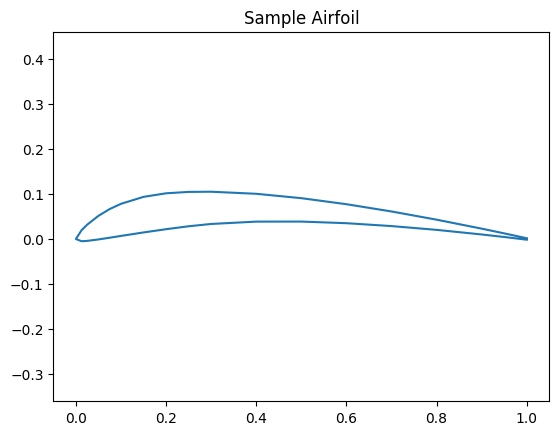

In [2]:
import matplotlib.pyplot as plt

sample = airfoils[0]

plt.plot(sample[:,0], sample[:,1])
plt.title("Sample Airfoil")
plt.axis('equal')
plt.show()

In [3]:
import numpy as np

def resample_airfoil(coords, n_points=100):
    coords = np.array(coords)

    # distance between consecutive points
    d = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    d = np.insert(np.cumsum(d), 0, 0)

    # new equally spaced distances
    new_d = np.linspace(0, d[-1], n_points)

    # interpolate x and y separately
    new_x = np.interp(new_d, d, coords[:, 0])
    new_y = np.interp(new_d, d, coords[:, 1])

    return np.stack([new_x, new_y], axis=1)

resampled_airfoils = []

for airfoil in airfoils:
    if len(airfoil) > 10:
        resampled = resample_airfoil(airfoil, n_points=100)
        resampled_airfoils.append(resampled)

print("Total resampled airfoils:", len(resampled_airfoils))
print("Shape of one airfoil:", resampled_airfoils[0].shape)

Total resampled airfoils: 1665
Shape of one airfoil: (100, 2)


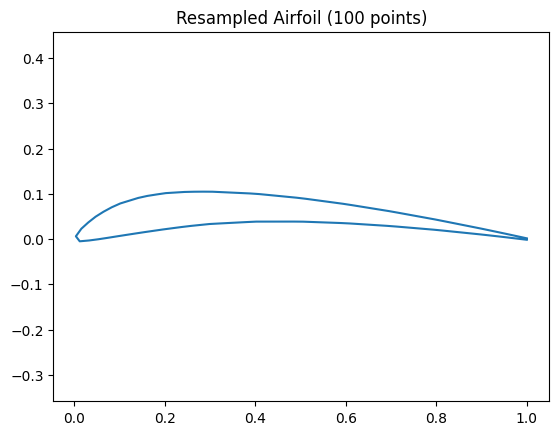

In [4]:
sample_resampled = resampled_airfoils[0]

plt.plot(sample_resampled[:, 0], sample_resampled[:, 1])
plt.title("Resampled Airfoil (100 points)")
plt.axis("equal")
plt.show()

In [4]:
X = np.array(resampled_airfoils)
print("Dataset shape:", X.shape)

Dataset shape: (1665, 100, 2)


In [5]:
X_flat = X.reshape(X.shape[0], -1)
print("Flattened shape:", X_flat.shape)

Flattened shape: (1665, 200)


In [6]:
X_min = X_flat.min()
X_max = X_flat.max()

X_norm = 2 * (X_flat - X_min) / (X_max - X_min) - 1

print("Normalized data shape:", X_norm.shape)
print("Min value:", X_norm.min())
print("Max value:", X_norm.max())

Normalized data shape: (1665, 200)
Min value: -1.0
Max value: 1.0


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [8]:
!pip install tensorflow

In [9]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [10]:
latent_dim = 50
data_dim = X_norm.shape[1]   # 200

def build_generator():
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(data_dim, activation='tanh')
    ])
    return model

generator = build_generator()
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           6,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 200)                 │          51,400 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,952 (355.28 KB)

 Trainable params: 90,952 (355.28 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def build_discriminator():
    model = models.Sequential([
        layers.Input(shape=(data_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │          51,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 84,481 (330.00 KB)

 Trainable params: 84,481 (330.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
discriminator.trainable = False

gan_input = layers.Input(shape=(latent_dim,))
generated_airfoil = generator(gan_input)
gan_output = discriminator(generated_airfoil)

gan = models.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

gan.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 200)                 │          90,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 1)                   │          84,481 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 175,433 (685.29 KB)

 Trainable params: 90,952 (355.28 KB)

 Non-trainable params: 84,481 (330.00 KB)

In [13]:
batch_size = 32
epochs = 3000

real_label = np.ones((batch_size, 1))
fake_label = np.zeros((batch_size, 1))

In [14]:
d_losses = []
g_losses = []

for epoch in range(epochs):
    # Train discriminator
    idx = np.random.randint(0, X_norm.shape[0], batch_size)
    real_airfoils = X_norm[idx]

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_airfoils = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real_airfoils, real_label)
    d_loss_fake = discriminator.train_on_batch(fake_airfoils, fake_label)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    discriminator.trainable = False
    g_loss = gan.train_on_batch(noise, real_label)

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f}, D Acc: {d_loss[1]*100:.2f}% | G Loss: {g_loss:.4f}")

Epoch 0 | D Loss: 0.8962, D Acc: 22.66% | G Loss: 0.8084
Epoch 200 | D Loss: 0.0394, D Acc: 99.22% | G Loss: 6.2295
Epoch 400 | D Loss: 0.0930, D Acc: 97.92% | G Loss: 5.9442
Epoch 600 | D Loss: 0.1321, D Acc: 96.81% | G Loss: 5.3951
Epoch 800 | D Loss: 0.1626, D Acc: 95.96% | G Loss: 4.9623
Epoch 1000 | D Loss: 0.2007, D Acc: 93.87% | G Loss: 4.6131
Epoch 1200 | D Loss: 0.2205, D Acc: 92.97% | G Loss: 4.4591
Epoch 1400 | D Loss: 0.2605, D Acc: 91.18% | G Loss: 4.2736
Epoch 1600 | D Loss: 0.2687, D Acc: 91.13% | G Loss: 4.0674
Epoch 1800 | D Loss: 0.2978, D Acc: 89.67% | G Loss: 3.9186
Epoch 2000 | D Loss: 0.3217, D Acc: 88.86% | G Loss: 3.7452
Epoch 2200 | D Loss: 0.3446, D Acc: 87.34% | G Loss: 3.5881
Epoch 2400 | D Loss: 0.3620, D Acc: 86.11% | G Loss: 3.4799
Epoch 2600 | D Loss: 0.3765, D Acc: 85.38% | G Loss: 3.3567
Epoch 2800 | D Loss: 0.3893, D Acc: 84.66% | G Loss: 3.2641


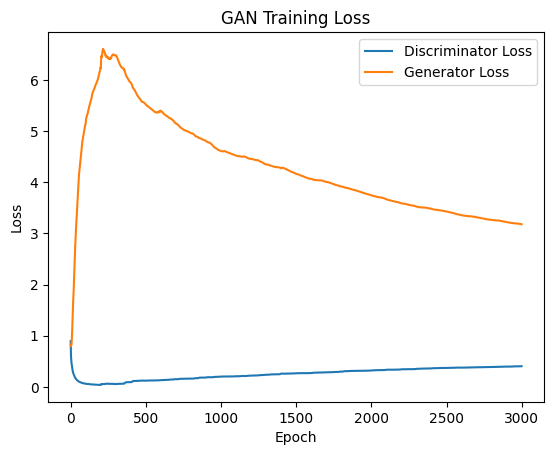

In [15]:
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

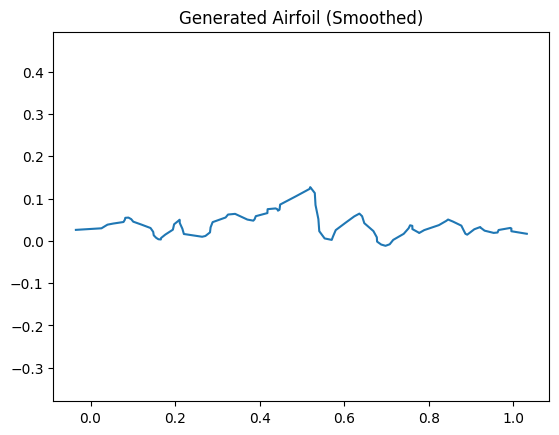

In [18]:
from scipy.ndimage import gaussian_filter1d

noise = np.random.normal(0, 1, (1, latent_dim))
generated = generator.predict(noise, verbose=0)

generated_airfoil = generated.reshape(100, 2)

# denormalize
generated_airfoil = (generated_airfoil + 1) / 2 * (X_max - X_min) + X_min

# sort by x
generated_airfoil = generated_airfoil[generated_airfoil[:,0].argsort()]

# smooth y-values
generated_airfoil[:,1] = gaussian_filter1d(generated_airfoil[:,1], sigma=2)

plt.plot(generated_airfoil[:, 0], generated_airfoil[:, 1])
plt.title("Generated Airfoil (Smoothed)")
plt.axis("equal")
plt.show()